In [16]:
import json
import torch
import PIL
import supervision as sv
import numpy as np
import matplotlib.pyplot as plt
import random
import rich
import segmentation_models_pytorch as smp

from torchinfo import summary
from rich.progress import Progress
from segmentation_models_pytorch.losses import DiceLoss
from segmentation_models_pytorch.encoders import get_preprocessing_fn
from segmentation_models_pytorch import Unet
from PIL import Image
from torch.utils.data import Dataset, DataLoader

In [17]:
# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

In [1]:
!unzip -q Segmentation_Data.zip

# DATA LOADING

In [18]:
class BrainMRIDataSet(Dataset):
    def __init__(self, annotation_path, transform=None):
        self.transform = transform
        self.annotation_path = annotation_path
        # Sort by file name for reproducibility
        self.data = sorted(self.get_data(self.annotation_path), key=lambda x: x["metadata"]["id"])
        
    def __getitem__(self, idx):
        item_data = self.data[idx]
        image_id = item_data["metadata"]["id"]
        file_name = item_data["metadata"]["file_name"]
        image_width = item_data["metadata"]["image_width"]
        image_height = item_data["metadata"]["image_height"]
        tumor_status = item_data["annotations"]["tumor_status"]
        polygons = item_data["annotations"]["segmentation_poly"]

        image = Image.open(f"{self.annotation_path.replace('_annotations.coco.json', file_name)}").convert("RGB")
        image = np.array(image)

        if self.transform is not None:
            image = self.transform(image)
        
        if tumor_status == 1:
            # Generate segmentation mask from polygons
            # Reshape the flatten polygon coordinates into list of vertices
            mask = [sv.polygon_to_mask(np.array(p).reshape(-1, 2), (image_width, image_height)) for p in polygons]
        else:
            # If no tumor, create an empty mask
            mask = [np.zeros(shape=(image_height, image_width))]

        # Convert image to CHW format since Pytorch uses that format.
        # Convert mask from HW to 1HW since it is required for training
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask[0]).unsqueeze(0).float()
        
        return mask, image, image_id
        
    def __len__(self):
        return len(self.data)

    @staticmethod
    def get_data(annotation_path: str) -> list[dict]:
        with open(annotation_path, "r") as f:
            data = json.load(f)
        
        data.pop("info")
        data.pop("licenses")
        data.pop("categories")
        
        output = []
        
        for i in range(len(data["images"])):
            # Get the meta data of the corresponding image
            image_data = data["images"][i]
            image_id = image_data["id"]
            image_width = image_data["width"]
            image_height = image_data["height"]
            file_name = image_data["file_name"]
        
            # Get the annotation of the corresponding image
            # Note: data["images"][i] and data["annotations"][i] are the meta data and annotation of the same image.
            # Which is why we keep track of index i
            image_annotation = data["annotations"][i]
            # Change category id into a boolean flag. Category id 1 denotes no tumor (0) and category id 2 denotes presence of tumor (1)
            tumor_status = image_annotation["category_id"] - 1
        
            if tumor_status == 1:
                bbox = image_annotation["bbox"] # Format: [x_top_left, y_top_left, width, height] (Note: Everything is in raw pixel, not normalized)
                segmentation_poly = image_annotation["segmentation"]
            else:
                bbox = []
                segmentation_poly = []
        
            # Put everything into a result dict
            result = {"metadata": {"image_width": image_width,
                                   "image_height": image_height,
                                   "file_name": file_name,
                                   "id": image_id},
                      "annotations": {"tumor_status": tumor_status,
                                      "bbox": bbox,
                                      "segmentation_poly": segmentation_poly}}
        
            # Save the result
            output.append(result)
    
        return output

In [19]:
preprocess_input = get_preprocessing_fn('efficientnet-b0', pretrained='imagenet')

# TRAIN DATASET + DATALOADER
train_dataset = BrainMRIDataSet(annotation_path=r"/home/sagemaker-user/A3/train/_annotations.coco.json", transform=preprocess_input)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=2, shuffle=True)

# VAL DATASET + DATALOADER (We use the test set as val set)
val_dataset = BrainMRIDataSet(annotation_path=r"/home/sagemaker-user/A3/test/_annotations.coco.json", transform=preprocess_input)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=2, shuffle=False)

In [9]:
mask, image, file_name = val_dataset[15]

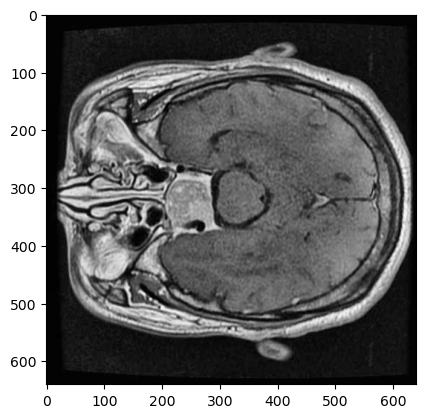

In [59]:
# Visualize with transform=None and before converting to tensor
plt.imshow(image)
plt.show()

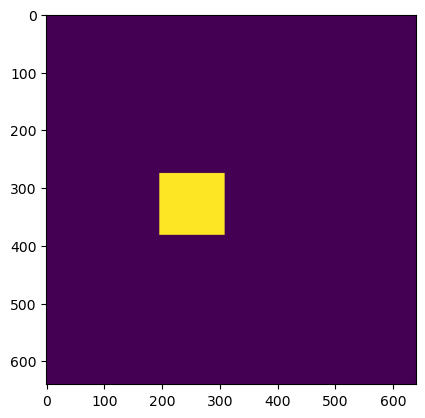

In [60]:
# Visualize with transform=None and before converting to tensor
plt.imshow(mask[0])
plt.show()

In [20]:
# Visualize with transform=None and before converting to tensor
def overlay_mask(image, mask, mask_type, alpha=0.4, pred_mask=None, denormalize=False):
    image = np.array(image)

    # Convert image back to raw pixel value if it has been scaled/normalized
    if denormalize:
        # Imagenet mean and std
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = (image * std) + mean
        image = np.clip(image, 0, 1)   # keep valid range
        image = image * 255
        
    # Create a colored mask
    colored_mask = np.zeros_like(image)

    if mask_type == "gt":
        colored_mask[:, :, 0] = mask * 255  # red channel
    elif mask_type == "pred":
        colored_mask[:, :, 1] = mask * 255  # green channel

    # Image + mask
    overlay = image.copy()
    overlay = (1 - alpha) * overlay + alpha * colored_mask
    
    overlay = overlay.astype(np.uint8)
    return overlay

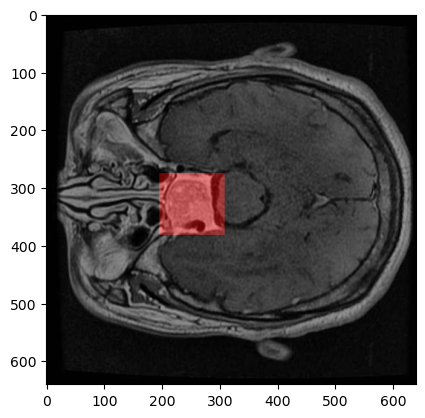

In [61]:
overlay = overlay_mask(image, mask[0], mask_type="gt")
plt.imshow(overlay)
plt.show()

# MODEL TRAINING

In [21]:
model = Unet(encoder_name="efficientnet-b0", encoder_depth=5, encoder_weights="imagenet", in_channels=3, classes=1)

In [7]:
summary(model)

Layer (type:depth-idx)                                  Param #
Unet                                                    --
├─EfficientNetEncoder: 1-1                              --
│    └─Conv2dStaticSamePadding: 2-1                     864
│    │    └─ZeroPad2d: 3-1                              --
│    └─BatchNorm2d: 2-2                                 64
│    └─ModuleList: 2-3                                  --
│    │    └─MBConvBlock: 3-2                            1,448
│    │    └─MBConvBlock: 3-3                            6,004
│    │    └─MBConvBlock: 3-4                            10,710
│    │    └─MBConvBlock: 3-5                            15,350
│    │    └─MBConvBlock: 3-6                            31,290
│    │    └─MBConvBlock: 3-7                            37,130
│    │    └─MBConvBlock: 3-8                            102,900
│    │    └─MBConvBlock: 3-9                            102,900
│    │    └─MBConvBlock: 3-10                           126,004
│    │    └─M

In [22]:
EPOCHS = 150
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OPTIMIZER = torch.optim.Adam(model.parameters(), lr=1e-4)
LOSS_FN = DiceLoss(mode="binary", from_logits=True)
NO_IMPROVE = 0
PATIENCE = 10
BEST_VAL_LOSS = float("inf")

In [8]:
model.to(DEVICE)

with Progress() as progress:
    epoch_counter = progress.add_task(description="EPOCH", total=EPOCHS)
    batch_counter = progress.add_task(description="BATCH", total=len(train_dataloader))

    # ================================ TRAINING ====================================
    for epoch in range(EPOCHS):
        train_loss = 0
        val_loss = 0
        model.train()
        
        for masks, images, _ in train_dataloader:
            images = images.to(DEVICE, dtype=torch.float32)
            masks = masks.to(DEVICE, dtype=torch.float32)
            logits_masks = model(images)  # (B, 1, H, W)
    
            loss = LOSS_FN(logits_masks, masks)
            OPTIMIZER.zero_grad()
            loss.backward()
            OPTIMIZER.step()
            train_loss += loss.item()
            progress.update(batch_counter, advance=1)

        # ============================== VALIDATING =====================================
        model.eval()
        with torch.inference_mode():
            for masks, images, _ in val_dataloader:
                images = images.to(DEVICE, dtype=torch.float32)
                masks = masks.to(DEVICE, dtype=torch.float32)
                logits_masks = model(images)  # (B, 1, H, W)
                
                loss = LOSS_FN(logits_masks, masks)
                val_loss += loss.item()

        # =========================== EARLY STOPPING ===============================
        if val_loss < BEST_VAL_LOSS:
            BEST_VAL_LOSS = val_loss
            NO_IMPROVE = 0
            model.save_pretrained('/home/sagemaker-user/A3')
        else:
            NO_IMPROVE += 1

        if NO_IMPROVE >= PATIENCE:
            print("Early stopping triggered")
            break
            
        print(f"Epoch {epoch} | Train loss = {train_loss / len(train_dataloader): .2f} | Val loss = {val_loss / len(val_dataloader): .2f}")
        progress.reset(batch_counter)
        progress.update(epoch_counter, advance=1)

Output()

Epoch 0 | Train loss =  0.57 | Val loss =  0.35

Epoch 1 | Train loss =  0.34 | Val loss =  0.22

Epoch 2 | Train loss =  0.29 | Val loss =  0.20

Epoch 3 | Train loss =  0.25 | Val loss =  0.20

...

Epoch 11 | Train loss =  0.17 | Val loss =  0.17

Epoch 12 | Train loss =  0.17 | Val loss =  0.21

Epoch 13 | Train loss =  0.16 | Val loss =  0.17

Epoch 14 | Train loss =  0.14 | Val loss =  0.21

Early stopping triggered

# MODEL EVALUATION

In [23]:
# Load trained weights into model
model = smp.from_pretrained('/home/sagemaker-user/A3')
model.to(DEVICE)
model.eval()

summary(model)

Loading weights from local directory


Layer (type:depth-idx)                                  Param #
Unet                                                    --
├─EfficientNetEncoder: 1-1                              --
│    └─Conv2dStaticSamePadding: 2-1                     864
│    │    └─ZeroPad2d: 3-1                              --
│    └─BatchNorm2d: 2-2                                 64
│    └─ModuleList: 2-3                                  --
│    │    └─MBConvBlock: 3-2                            1,448
│    │    └─MBConvBlock: 3-3                            6,004
│    │    └─MBConvBlock: 3-4                            10,710
│    │    └─MBConvBlock: 3-5                            15,350
│    │    └─MBConvBlock: 3-6                            31,290
│    │    └─MBConvBlock: 3-7                            37,130
│    │    └─MBConvBlock: 3-8                            102,900
│    │    └─MBConvBlock: 3-9                            102,900
│    │    └─MBConvBlock: 3-10                           126,004
│    │    └─M

In [10]:
def evaluate_model(model, dataloader) -> tuple:
    model.eval()
    tps, fps, fns, tns = [], [], [], []
    
    with torch.inference_mode():
        for masks, images, _ in dataloader:
            masks = masks.to(DEVICE)
            images = images.to(DEVICE)
    
            # Get predicted masks
            logits_masks = model(images)
            prob_mask = torch.sigmoid(logits_masks)
            pred_mask = (prob_mask > 0.5).float()
    
            # Calculate true positive, false positive, true negative, and false positive of each image per batch
            tp, fp, fn, tn = smp.metrics.get_stats(pred_mask.long(), masks.long(), mode="binary")
            tps.append(tp.cpu())
            fps.append(fp.cpu())
            fns.append(fn.cpu())
            tns.append(tn.cpu())
    
    tps = torch.concat(tps)
    fps = torch.concat(fps)
    fns = torch.concat(fns)
    tns = torch.concat(tns)
    
    # per image IoU means that we first calculate IoU score for each image
    # and then compute mean over these scores
    per_image_iou = smp.metrics.iou_score(tps, fps, fns, tns, reduction="micro-imagewise").item()
    
    # dataset IoU means that we aggregate intersection and union over whole dataset
    # and then compute IoU score. The difference between dataset_iou and per_image_iou scores
    # in this particular case will not be much, however for dataset
    # with "empty" images (images without target class) a large gap could be observed.
    # Empty images influence a lot on per_image_iou and much less on dataset_iou.
    dataset_iou = smp.metrics.iou_score(tps, fps, fns, tns, reduction="micro").item()
    balanced_accuracy = smp.metrics.balanced_accuracy(tps, fps, fns, tns,  reduction="micro-imagewise").item()
    return (per_image_iou, dataset_iou, balanced_accuracy)

In [12]:
# Performance of model on training set
per_image_iou, dataset_iou, balanced_accuracy = evaluate_model(model, train_dataloader)
print(f"per_image_iou: {per_image_iou: .3f}")
print(f"dataset_iou: {dataset_iou: .3f}")
print(f"balanced_accuracy: {balanced_accuracy: .3f}")

per_image_iou:  0.699
dataset_iou:  0.544
balanced_accuracy:  0.942


In [11]:
# Performance of model on validation set
per_image_iou, dataset_iou, balanced_accuracy = evaluate_model(model, val_dataloader)
print(f"per_image_iou: {per_image_iou: .3f}")
print(f"dataset_iou: {dataset_iou: .3f}")
print(f"balanced_accuracy: {balanced_accuracy: .3f}")

per_image_iou:  0.728
dataset_iou:  0.632
balanced_accuracy:  0.965


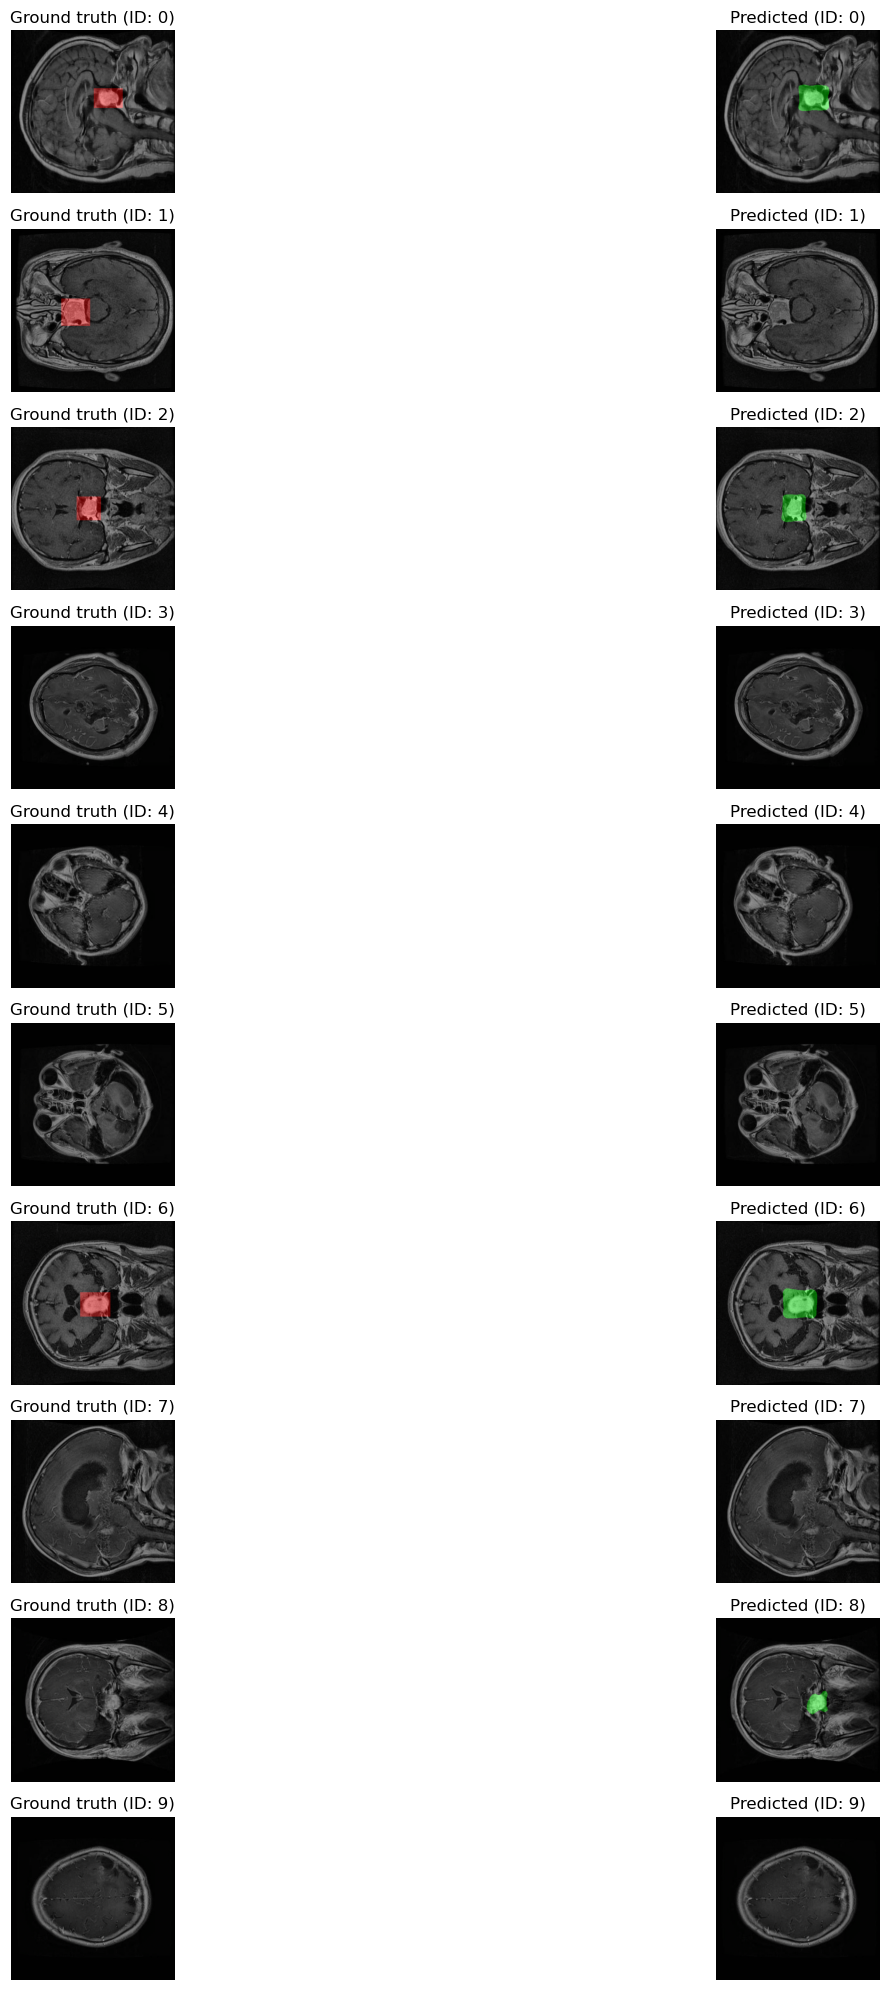

In [24]:
# Plot ground truth mask and predicted mask
fig, ax = plt.subplots(nrows=10, ncols=2, figsize=(20, 20))
image_counter = 0 # Keep track of how many images have displayed both the predicted and ground truth masks

model.eval()
with torch.inference_mode():
    for masks, images, image_ids in val_dataloader:
        masks = masks.to(DEVICE)
        images = images.to(DEVICE)
        
        logits_masks = model(images)
        prob_mask = torch.sigmoid(logits_masks)
        pred_mask = (prob_mask > 0.5).float()

        # Move to CPU and convert from tensor to numpy for visualization
        pred_mask = pred_mask.cpu().numpy()
        masks = masks.cpu().numpy()
        
        # =========================== PLOTTING GROUND TRUTH VS PREDICTED MASKS ==============================
        for i in range(2): # images = [image1, image2], pred_mask = [prediction mask for img1, prediction mask for img2], masks = [ground truth mask of img1, ground truth mask of img2]
            # Convert from tensor to ndarray and from CHW format to HWC format for visualization.
            image = images[i].permute(1, 2, 0).cpu().numpy()
            image_id = image_ids[i]
            
            # Get the corresponding predicted and ground truth masks
            pred_mask = pred_mask[i][0]
            ground_truth_mask = masks[i][0]

            # Overlay the ground truth mask
            overlay = overlay_mask(image, ground_truth_mask, mask_type="gt", denormalize=True)
            ax[image_counter][0].imshow(overlay)
            ax[image_counter][0].axis("off")
            ax[image_counter][0].set_title(f"Ground truth (ID: {image_id})")
            
            # Overlay the predicted mask
            overlay = overlay_mask(image, pred_mask, mask_type="pred", denormalize=True)
            ax[image_counter][1].imshow(overlay)
            ax[image_counter][1].axis("off")
            ax[image_counter][1].set_title(f"Predicted (ID: {image_id})")

            image_counter += 1
            
        # Only visualize first 5 batches (10 images total)
        if image_counter == 10:
            break

plt.tight_layout()
plt.show()